In [ ]:
# =========================================================
# 1: IMPORT LIBRARY & MOUNT GOOGLE DRIVE
# =========================================================
import os
import random
import shutil
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler

# Mount Google Drive
drive.mount('/content/drive')

print("✅ 1 Selesai: Library dan Drive berhasil disiapkan!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ 1 Selesai: Library dan Drive berhasil disiapkan!


In [ ]:
# =========================================================
# 2: FUNGSI PEMBUATAN SUBSET DATASET (200 & 350)
# =========================================================
source_dir = '/content/drive/MyDrive/Colab Notebooks/Citra Daun Padi'

def buat_subset_dataset(nama_folder_tujuan, jumlah_blast, jumlah_blight, jumlah_tungro):
    dest_dir = f'/content/{nama_folder_tujuan}'

    # RESET FOLDER: Jika folder sudah ada, hapus beserta isinya mencegah numpuk
    if os.path.exists(dest_dir):
        shutil.rmtree(dest_dir)
        print(f"🔄 Me-reset folder '{nama_folder_tujuan}' lama...")

    kelas = ['blast', 'blight', 'tungro']
    jumlah_kebutuhan = [jumlah_blast, jumlah_blight, jumlah_tungro]

    # Buat folder tujuan baru
    for k in kelas:
        os.makedirs(os.path.join(dest_dir, k), exist_ok=True)

    for i, k in enumerate(kelas):
        folder_sumber_kelas = os.path.join(source_dir, k)

        if not os.path.exists(folder_sumber_kelas):
            print(f"❌ ERROR: Folder tidak ditemukan di {folder_sumber_kelas}")
            return

        semua_file = [f for f in os.listdir(folder_sumber_kelas) if os.path.isfile(os.path.join(folder_sumber_kelas, f))]
        jumlah_tersedia = len(semua_file)

        if jumlah_tersedia < jumlah_kebutuhan[i]:
            print(f"❌ ERROR: Gambar {k} hanya ada {jumlah_tersedia}, butuh {jumlah_kebutuhan[i]}.")
            return

        sampel_file = random.sample(semua_file, jumlah_kebutuhan[i])
        folder_tujuan_kelas = os.path.join(dest_dir, k)

        for file in sampel_file:
            src_path = os.path.join(folder_sumber_kelas, file)
            dst_path = os.path.join(folder_tujuan_kelas, file)
            shutil.copy(src_path, dst_path)

    print(f"✅ Dataset '{nama_folder_tujuan}' BERHASIL DIBUAT!")
    print(f"   - Blast: {jumlah_blast} | Blight: {jumlah_blight} | Tungro: {jumlah_tungro} | Total: {sum(jumlah_kebutuhan)}\n")

# Eksekusi Pembuatan Dataset
print("\n--- Memulai Proses Pembuatan Dataset ---")
buat_subset_dataset('dataset_200', jumlah_blast=120, jumlah_blight=50, jumlah_tungro=30)
buat_subset_dataset('dataset_350', jumlah_blast=150, jumlah_blight=160, jumlah_tungro=40)
buat_subset_dataset('dataset_500', jumlah_blast=200, jumlah_blight=220, jumlah_tungro=80)



--- Memulai Proses Pembuatan Dataset ---
🔄 Me-reset folder 'dataset_200' lama...
✅ Dataset 'dataset_200' BERHASIL DIBUAT!
   - Blast: 120 | Blight: 50 | Tungro: 30 | Total: 200

🔄 Me-reset folder 'dataset_350' lama...
✅ Dataset 'dataset_350' BERHASIL DIBUAT!
   - Blast: 150 | Blight: 160 | Tungro: 40 | Total: 350

🔄 Me-reset folder 'dataset_500' lama...
✅ Dataset 'dataset_500' BERHASIL DIBUAT!
   - Blast: 200 | Blight: 220 | Tungro: 80 | Total: 500



In [ ]:
# =========================================================
# 3: MESIN EKSTRAKSI FITUR (HSV & SHAPE)
# =========================================================
def extract_color_histogram(image, bins=(8, 8, 8)):
    hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    hist_hue = cv2.calcHist([hsv_image], [0], None, [bins[0]], [0, 256])
    hist_saturation = cv2.calcHist([hsv_image], [1], None, [bins[1]], [0, 256])
    hist_value = cv2.calcHist([hsv_image], [2], None, [bins[2]], [0, 256])

    hist_hue = cv2.normalize(hist_hue, hist_hue).flatten()
    hist_saturation = cv2.normalize(hist_saturation, hist_saturation).flatten()
    hist_value = cv2.normalize(hist_value, hist_value).flatten()

    return np.hstack([hist_hue, hist_saturation, hist_value])

def extract_shape_features(image):
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    _, thresholded_image = cv2.threshold(gray_image, 127, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresholded_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    area = sum(cv2.contourArea(c) for c in contours)
    perimeter = sum(cv2.arcLength(c, True) for c in contours)

    return np.array([area, perimeter])

def extract_all_features(image):
    color_features = extract_color_histogram(image)
    shape_features = extract_shape_features(image)
    return np.hstack([color_features, shape_features])

def load_and_extract(data_dir, img_size=(224, 224)):
    feature_vectors = []
    labels = []
    classes = ['blast', 'blight', 'tungro']

    for idx, cls in enumerate(classes):
        cls_dir = os.path.join(data_dir, cls)
        if not os.path.exists(cls_dir):
            continue

        for image_file in os.listdir(cls_dir):
            image_path = os.path.join(cls_dir, image_file)
            image = cv2.imread(image_path)

            if image is not None:
                image = cv2.resize(image, img_size)
                features = extract_all_features(image)
                feature_vectors.append(features)
                labels.append(idx)

    return np.array(feature_vectors), np.array(labels), classes

print("✅ 3 Selesai: Fungsi Ekstraksi Fitur siap!")

✅ 3 Selesai: Fungsi Ekstraksi Fitur siap!


--- Memproses Dataset NON-BALANCING (200, 350, 500) ---

Mengekstrak fitur untuk Non-Balancing 200...

--- Hasil Kinerja: Random Forest ---
Akurasi   : 92.50%
Presisi   : 96.30%
Recall    : 85.56%
F1-Score  : 89.62%

--- Hasil Kinerja: SVM ---
Akurasi   : 92.50%
Presisi   : 96.30%
Recall    : 83.33%
F1-Score  : 86.93%

--- Hasil Kinerja: KNN ---
Akurasi   : 87.50%
Presisi   : 86.73%
Recall    : 78.61%
F1-Score  : 81.64%


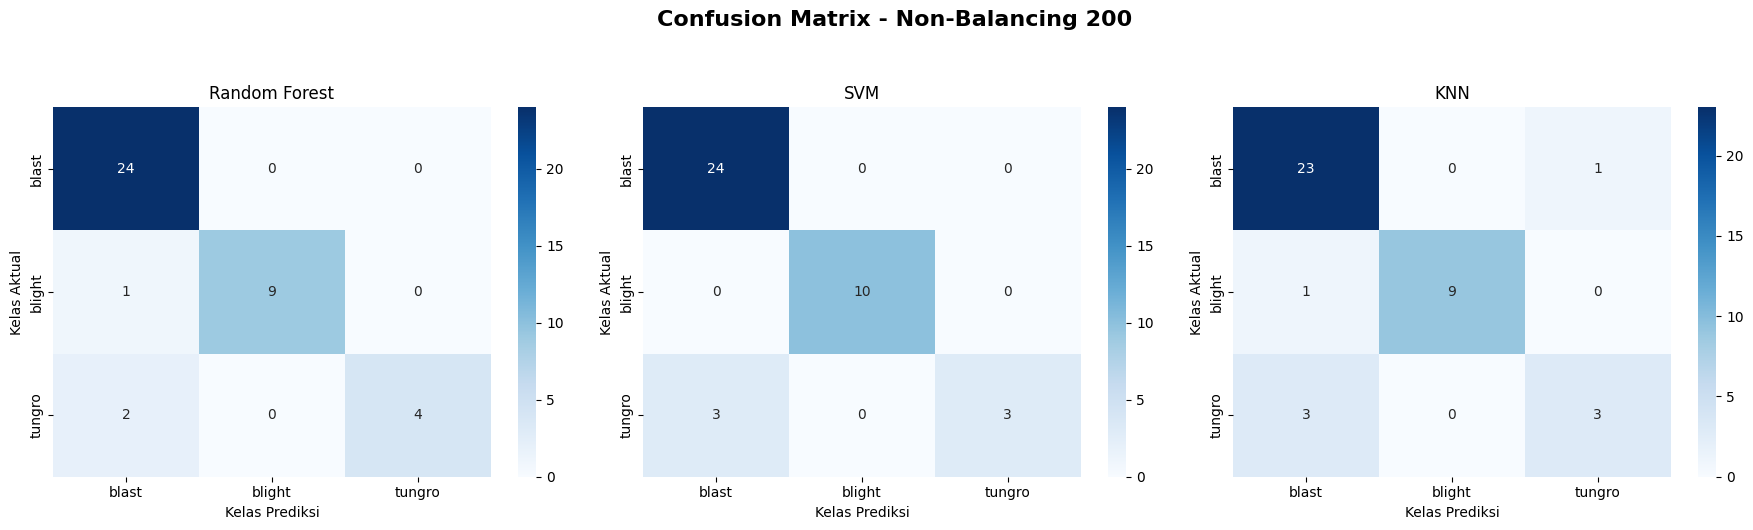

Mengekstrak fitur untuk Non-Balancing 350...

--- Hasil Kinerja: Random Forest ---
Akurasi   : 94.29%
Presisi   : 96.08%
Recall    : 86.46%
F1-Score  : 89.70%

--- Hasil Kinerja: SVM ---
Akurasi   : 87.14%
Presisi   : 85.30%
Recall    : 77.99%
F1-Score  : 80.37%

--- Hasil Kinerja: KNN ---
Akurasi   : 88.57%
Presisi   : 83.17%
Recall    : 79.10%
F1-Score  : 80.49%


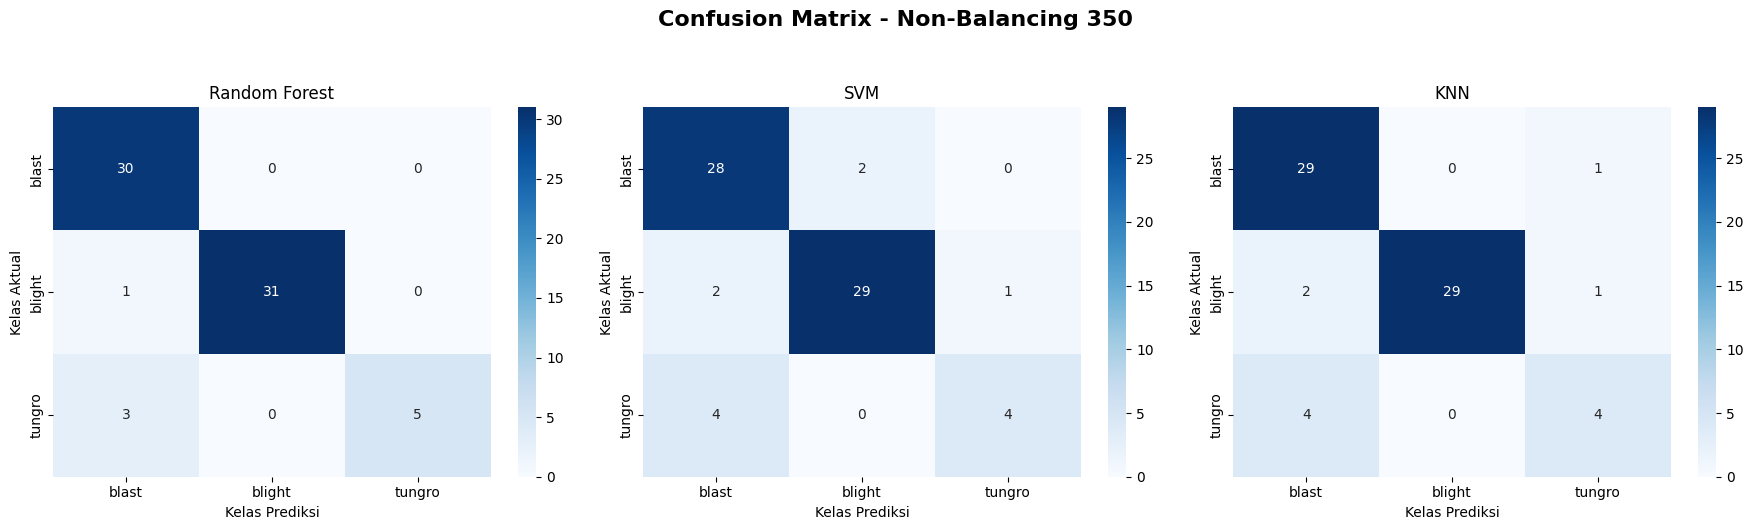

Mengekstrak fitur untuk Non-Balancing 500...

--- Hasil Kinerja: Random Forest ---
Akurasi   : 95.00%
Presisi   : 96.21%
Recall    : 90.91%
F1-Score  : 92.89%

--- Hasil Kinerja: SVM ---
Akurasi   : 95.00%
Presisi   : 94.34%
Recall    : 90.83%
F1-Score  : 92.24%

--- Hasil Kinerja: KNN ---
Akurasi   : 91.00%
Presisi   : 87.60%
Recall    : 87.58%
F1-Score  : 87.58%


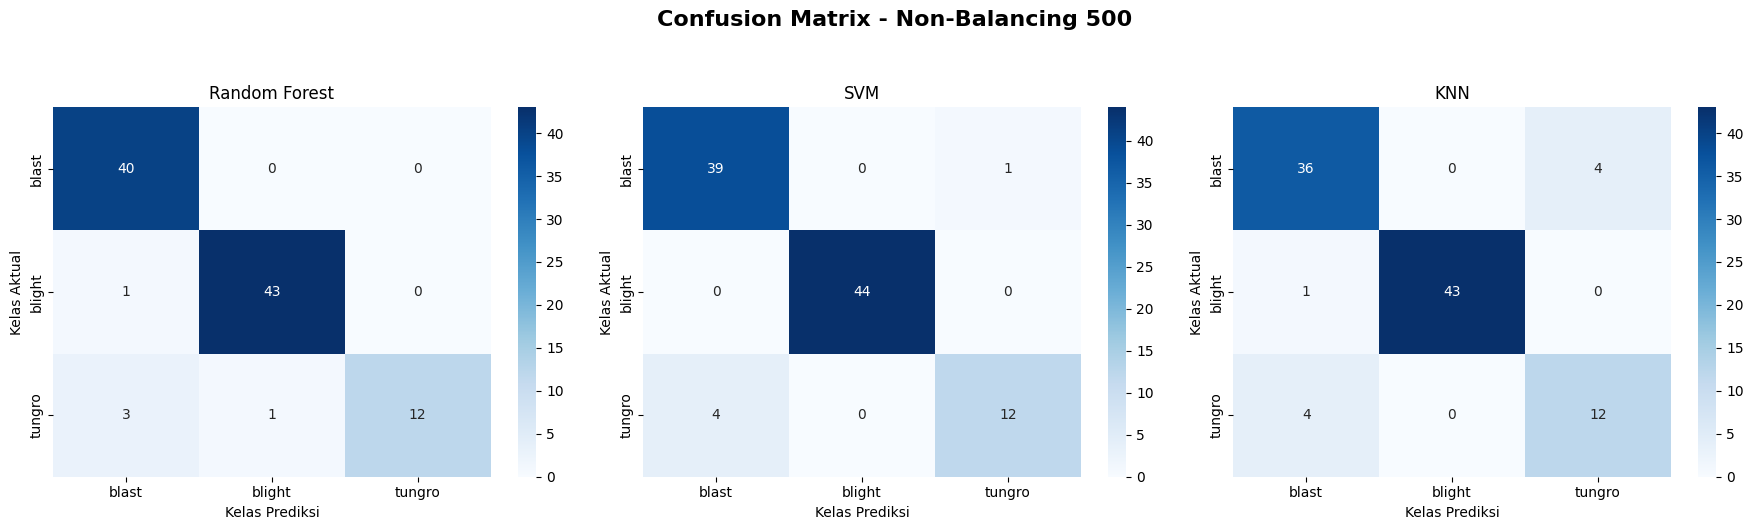

In [ ]:
# =========================================================
# 4: PROSES TRAINING & EVALUASI MODEL
# =========================================================
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='linear', random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

datasets_non_bal = {
    'Non-Balancing 200': '/content/dataset_200',
    'Non-Balancing 350': '/content/dataset_350',
    'Non-Balancing 500': '/content/dataset_500'
}

print("--- Memproses Dataset NON-BALANCING (200, 350, 500) ---\n")

for ds_name, ds_path in datasets_non_bal.items():
    print(f"{'='*60}")
    print(f"Mengekstrak fitur untuk {ds_name}...")
    X, y, target_names = load_and_extract(ds_path)

    if len(X) == 0:
        print(f"❌ Data kosong di {ds_path}. Pastikan path benar.")
        continue

    # 1. Split Data DULU sebelum normalisasi (Penting untuk hindari Data Leakage)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # 2. Normalisasi Data
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train) # Belajar dari data latih
    X_test = scaler.transform(X_test)       # Terapkan ke data uji

    # 3. Menyiapkan Kanvas Visualisasi
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Confusion Matrix - {ds_name}', fontsize=16, fontweight='bold', y=1.05)

    for ax, (model_name, model) in zip(axes, models.items()):
        # Melatih & Memprediksi
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # Menghitung Metrik (menggunakan macro karena kelas data non-balance)
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
        rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

        # Mencetak Hasil
        print(f"\n--- Hasil Kinerja: {model_name} ---")
        print(f"Akurasi   : {acc*100:.2f}%")
        print(f"Presisi   : {prec*100:.2f}%")
        print(f"Recall    : {rec*100:.2f}%")
        print(f"F1-Score  : {f1*100:.2f}%")

        # Membuat Heatmap Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names, ax=ax)
        ax.set_title(f'{model_name}')
        ax.set_xlabel('Kelas Prediksi')
        ax.set_ylabel('Kelas Aktual')

    plt.tight_layout()
    plt.show()